In [1]:
# --! include root folders into PYTHONPATH --!

import os
import sys

dir_this = os.getcwd()
dir_example = os.path.abspath(os.path.join(dir_this, '..'))
sys.path.append(dir_example)
dir_root = os.path.abspath(os.path.join(dir_this, '..', '..', '..'))
sys.path.append(dir_root)

import torch
import torch.nn.functional as F
import numpy as np
import random
from matplotlib import pyplot as plt

import example_mujoco
import util_data
import util_nn

data_dir = '../../../data/mujoco/walker2d'
model_dir = '../../../models/mujoco/walker2d'
result_dir = '../../../results/mujoco/walker2d'

data_suffix = ''

In [2]:
# --! initialize random seed

seeds = [3, 123, 2026, 8192, 65536]
seed = seeds[4]

util_nn.set_seed(seed)

print(f'setting seed {seed}')

setting seed 65536


### Creating baseline dataset

In [3]:
data_nsample = 918
data = util_data.read_datafile(f'{data_dir}/baseline{data_suffix}', data_nsample)
print(f'read data shape: {data.shape}')

obs_ndim = 17
act_ndim = 6
obs, act = torch.split(data, [obs_ndim, act_ndim], dim=-1)
print(f'read observations shape: {obs.shape}')
print(f'read actions shape: {act.shape}')

std_min = torch.tensor(1e-3, dtype=torch.float32)

# --! get normalization constants per observation
obs_mean = [s.mean() for s in torch.split(obs, 1, dim=-1)]
obs_std = [torch.maximum(s.std(), std_min) for s in torch.split(obs, 1, dim=-1)]

# --! normalize observations
obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

train_obs = obs[:, :-1]
train_next_obs = obs[:, 1:]
train_act = act[:, :-1]
print(f'shape of observations for training: {train_obs.shape}')
print(f'shape of next observations for training: {train_next_obs.shape}')
print(f'shape of actions for training: {train_act.shape}')

dataloaders = []
nmodel = 7

for _ in range(nmodel):
    dataset = example_mujoco.baseline_dataset(train_obs, train_act, train_next_obs)
    dataloaders.append(torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True))

read data shape: torch.Size([50, 918, 23])
read observations shape: torch.Size([50, 918, 17])
read actions shape: torch.Size([50, 918, 6])
shape of observations for training: torch.Size([50, 917, 17])
shape of next observations for training: torch.Size([50, 917, 17])
shape of actions for training: torch.Size([50, 917, 6])


### Training an ensemble of models

In [4]:
model = example_mujoco.model_ensemble(nmodel, obs_ndim, act_ndim)
example_mujoco.train_ensemble(model, dataloaders, nepoch=500)

0 [array([-0.04817024]), array([-0.04638666]), array([-0.04765465]), array([-0.04659222]), array([-0.04670235]), array([-0.04758624]), array([-0.04831174])]
10 [array([-0.28332818]), array([-0.29209852]), array([-0.3102513]), array([-0.29955935]), array([-0.3153693]), array([-0.29584888]), array([-0.2778429])]
20 [array([-0.40316459]), array([-0.36817847]), array([-0.42492655]), array([-0.41404918]), array([-0.38840733]), array([-0.21739989]), array([-0.14952971])]
30 [array([-0.4491928]), array([-0.46464668]), array([-0.29082966]), array([-0.45847011]), array([-0.46571667]), array([-0.45219115]), array([-0.44415379])]
40 [array([-0.39846192]), array([-0.51607227]), array([-0.46463752]), array([-0.45754436]), array([-0.46760028]), array([-0.1226289]), array([-0.43722422])]
50 [array([-0.47183677]), array([-0.49034701]), array([-0.43406146]), array([-0.45221301]), array([-0.4759312]), array([-0.43383261]), array([-0.45221458])]
60 [array([-0.48647502]), array([-0.52182988]), array([-0.4

In [5]:
# --! compute model capacity

nparam = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'number of trainable parameters in model ensemble: {nparam/1e6}M')

number of trainable parameters in model ensemble: 2.04694M


In [6]:
modelsaved = False

if modelsaved:
    for j, m in enumerate(model.models):
        torch.save(m.state_dict(), f'{model_dir}/ensemble_checkpoint{data_suffix}_{nmodel}_{j}.pth')

# Evaluating ensemble baseline

In [7]:
eval_data = util_data.read_datafile(f'{data_dir}/eval', data_nsample)
print(f'read evaluation data shape: {eval_data.shape}')

eval_obs, eval_act = torch.split(eval_data, [obs_ndim, act_ndim], dim=-1)
print(f'read evaluation observations shape: {eval_obs.shape}')
print(f'read evaluation actions shape: {eval_act.shape}')

# --! normalize evaluation data
eval_obs = torch.cat([
    example_mujoco.normalize_standard(
        s, mean, std) for s, mean, std in zip(torch.split(eval_obs, 1, dim=-1), obs_mean, obs_std)], dim=-1)

read evaluation data shape: torch.Size([30, 918, 23])
read evaluation observations shape: torch.Size([30, 918, 17])
read evaluation actions shape: torch.Size([30, 918, 6])


In [18]:
this_traj = 11
deterministic = True
reanchor_nsample = 1_000_000 # ensure no re-anchoring

s0 = eval_obs[this_traj, 0]
rollout_traj = example_mujoco.rollout_ensemble(
    model, s0,
    eval_obs[this_traj], eval_act[this_traj],
    deterministic=deterministic, reanchor_nsample=reanchor_nsample)
print(f'rollout shape: {rollout_traj.shape}')

rollout shape: torch.Size([919, 17])


### Plotting rollout results

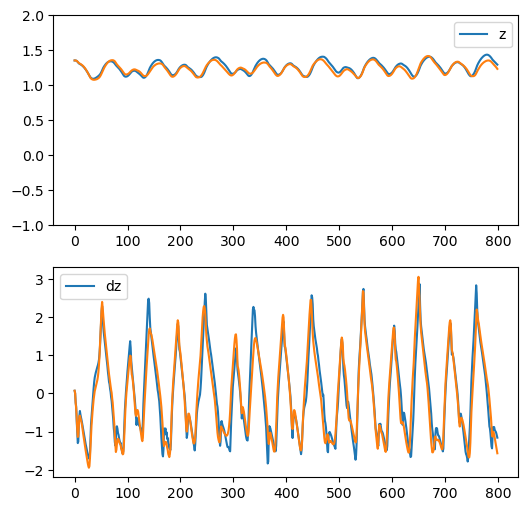

In [20]:
disp_end = 800
datasaved = False

plot_obs, plot_rollout = example_mujoco.disp_rollout(eval_obs, rollout_traj, obs_mean, obs_std, this_traj, disp_end)

if datasaved:
    rollout_type = 'deterministic' if deterministic else 'stochastic'
    save_step = torch.arange(eval_obs.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :disp_end, :1],
        plot_obs[[this_traj], :disp_end, :1], plot_obs[:1, :disp_end, [9]],
        plot_rollout[:1, :disp_end, :1], plot_rollout[:1, :disp_end, [9]]], axis=2)
    util_data.write_datafile(
        f'{result_dir}/ensemble_rollout{data_suffix}_type_{rollout_type}_nmodel_{nmodel}_seed_{seed}', savedata, delim=' ')

In [10]:
traj_mse = []
with torch.no_grad():
    for j in range(eval_obs.shape[0]): # trajectory
        print(f'processing trajectory {j+1} out of {eval_obs.shape[0]}')
        mse = []
        for h in range(1, eval_obs.shape[1]): # horizon
            s0 = eval_obs[j, 0]
            cmp_rollout = example_mujoco.rollout_ensemble(
                model, s0,
                eval_obs[j, :h], eval_act[j, :h],
                deterministic=deterministic, reanchor_nsample=reanchor_nsample)

            # --! denormalize results
            cmp_rollout = torch.unsqueeze(cmp_rollout, 0)
            cmp_rollout = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(cmp_rollout, 1, dim=-1), obs_mean, obs_std)], dim=-1)
            cmp_obs = torch.cat([
                example_mujoco.denormalize_standard(
                    s, mean, std) for s, mean, std in zip(torch.split(eval_obs[[j], :(h+1)], 1, dim=-1), obs_mean, obs_std)], dim=-1)

            # --! compute error
            loss = F.mse_loss(cmp_rollout, cmp_obs)
            mse.append(loss)
            if h % 100 == 0:
                print(f'\thorizon {h} out of {eval_obs.shape[1]}, loss: {loss}')
        mse = torch.stack(mse)
        traj_mse.append(mse)
    traj_mse = torch.stack(traj_mse)


processing trajectory 1 out of 30
	horizon 100 out of 918, loss: 1.5998528003692627
	horizon 200 out of 918, loss: 1.7676498889923096
	horizon 300 out of 918, loss: 2.4412434101104736
	horizon 400 out of 918, loss: 2.356949806213379
	horizon 500 out of 918, loss: 2.1447482109069824
	horizon 600 out of 918, loss: 2.3073136806488037
	horizon 700 out of 918, loss: 2.34767484664917
	horizon 800 out of 918, loss: 2.2650463581085205
	horizon 900 out of 918, loss: 2.3279471397399902
processing trajectory 2 out of 30
	horizon 100 out of 918, loss: 2.8200135231018066
	horizon 200 out of 918, loss: 2.3648550510406494
	horizon 300 out of 918, loss: 3.358628511428833
	horizon 400 out of 918, loss: 2.7811765670776367
	horizon 500 out of 918, loss: 2.858699083328247
	horizon 600 out of 918, loss: 2.6654858589172363
	horizon 700 out of 918, loss: 2.8437001705169678
	horizon 800 out of 918, loss: 2.949291944503784
	horizon 900 out of 918, loss: 2.8247053623199463
processing trajectory 3 out of 30
	hor

tensor(0.2275)
tensor(0.3005)
torch.Size([917])


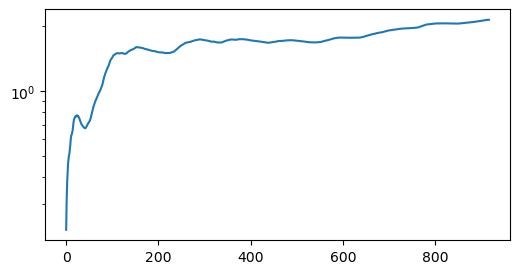

In [11]:
traj_mse_mean = torch.mean(traj_mse, dim=0)
traj_mse_std = torch.std(traj_mse, dim=0)

print(traj_mse_mean[0])
print(traj_mse_std[0])
print(traj_mse_mean.shape)

with torch.no_grad():
    plt.figure(figsize=(6,3))
    plt.semilogy(traj_mse_mean)
    plt.show()

horizon = 800
datasaved = True
if datasaved:
    rollout_type = 'deterministic' if deterministic else 'stochastic'
    save_mse_mean = traj_mse_mean.reshape(1, -1, 1)
    save_mse_std = traj_mse_std.reshape(1, -1, 1)
    save_step = torch.arange(traj_mse_mean.shape[0]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :horizon, :1],
        save_mse_mean[:1, :horizon, :1], save_mse_std[:1, :horizon, :1]], axis=2)
    util_data.write_datafile(
        f'{result_dir}/ensemble_mse{data_suffix}_type_{rollout_type}_nmodel_{nmodel}_seed_{seed}', savedata, delim=' ')

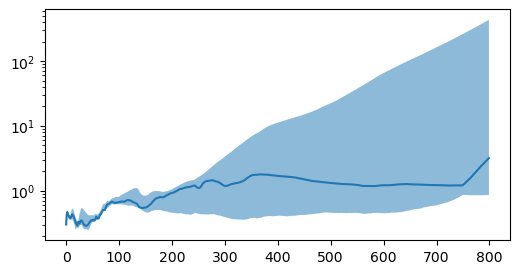

In [13]:
mseprocessed = True

if mseprocessed:
    length = 800
    mse_data = [
        util_data.read_datafile(
            f'{result_dir}/ensemble_mse{data_suffix}_type_deterministic_nmodel_7_seed_{s}', length, delim=' ') for s in seeds]
    mse = torch.cat([mse[..., [2]] for mse in mse_data], dim=0)
    mse_median, _ = torch.median(mse, dim=0, keepdim=True)
    mse_percentile_10 = torch.quantile(mse, 0.1, dim=0, keepdim=True)
    mse_percentile_90 = torch.quantile(mse, 0.9, dim=0, keepdim=True)

    x = torch.arange(mse_median.shape[1]).reshape(1, -1, 1)

    plt.figure(figsize=(6,3))
    plt.plot(x[0, :, 0], mse_median[0, :, 0], linestyle='solid')
    plt.fill_between(x[0, :, 0], mse_percentile_10[0, :, 0], mse_percentile_90[0, :, 0], alpha=0.5)
    plt.yscale('log')
    plt.show()

    horizon = disp_end
    nmse = mse.shape[0]
    save_step = torch.arange(mse_median.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :horizon, :1],
        mse_median[:1, :horizon, :1],
        mse_percentile_10[:1, :horizon, :1], mse_percentile_90[:1, :horizon, :1]], axis=2)
    util_data.write_datafile(f'{result_dir}/ensemble_mse_type_deterministic_nmodel_7_avg_{nmse}', savedata, delim=' ')